# Notebook 1: EDA & Preprocessing

Load data from a **SQLite database via SQL**, explore the Give Me Some Credit dataset, handle missing values, cap outliers, and engineer features.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing import impute_missing, cap_outliers, FEATURE_COLS, TARGET_COL
from src.features import engineer_features
from src.database import setup_db, query, DB_PATH

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Ingest CSV into SQLite

In production, data lives in a warehouse (Snowflake, Redshift, BigQuery). Here we replicate that workflow by ingesting the raw CSV into a **SQLite database**, then querying it with SQL using `pandas.read_sql_query()`.

> **Data download**: `kaggle competitions download -c GiveMeSomeCredit -p ../data/raw/` then unzip.

In [2]:
RAW_PATH = '../data/raw/cs-training.csv'
setup_db(RAW_PATH)
print(f"Database path: {DB_PATH}")

Database created at /Users/ryanchang/claude/credit-default-risk/data/processed/credit.db  (150,000 rows)
Database path: /Users/ryanchang/claude/credit-default-risk/data/processed/credit.db


## 3. Load Features via SQL

This query mirrors the feature extraction SQL in `sql/feature_extraction.sql` — the same logic that would run in a bank's data warehouse before any Python touches the data.

In [3]:
sql_load = '''
SELECT
    borrower_id,
    SeriousDlqin2yrs,
    RevolvingUtilizationOfUnsecuredLines,
    age,
    "NumberOfTime30-59DaysPastDueNotWorse",
    DebtRatio,
    MonthlyIncome,
    NumberOfOpenCreditLinesAndLoans,
    NumberOfTimes90DaysLate,
    NumberRealEstateLoansOrLines,
    "NumberOfTime60-89DaysPastDueNotWorse",
    NumberOfDependents
FROM borrowers
WHERE age BETWEEN 18 AND 100
'''
df_raw = query(sql_load)
print(f"Loaded {len(df_raw):,} rows via SQL")
df_raw.head()

Loaded 149,986 rows via SQL


,borrower_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 4. Analytical SQL: Default Rate by Age Bucket

This aggregation query runs entirely in SQL — no pandas needed. It's the kind of query you'd run in a data warehouse to understand segment-level risk before modeling.

In [4]:
sql_age = '''
SELECT
    CASE
        WHEN age < 25              THEN '18-24'
        WHEN age BETWEEN 25 AND 34 THEN '25-34'
        WHEN age BETWEEN 35 AND 49 THEN '35-49'
        WHEN age BETWEEN 50 AND 64 THEN '50-64'
        ELSE '65+'
    END AS age_bucket,
    COUNT(*)                               AS total_borrowers,
    SUM(SeriousDlqin2yrs)                 AS total_defaults,
    ROUND(AVG(SeriousDlqin2yrs) * 100, 2) AS default_rate_pct
FROM borrowers
GROUP BY age_bucket
ORDER BY age_bucket
'''
age_stats = query(sql_age)
print(age_stats.to_string(index=False))

age_bucket  total_borrowers  total_defaults  default_rate_pct
     18-24             2075             217             10.46
     25-34            17165            1933             11.26
     35-49            47141            4098              8.69
     50-64            52426            2996              5.71
       65+            31193             782              2.51


## 5. Analytical SQL: Delinquency Severity by Utilization Segment

In [5]:
sql_seg = '''
SELECT
    CASE
        WHEN RevolvingUtilizationOfUnsecuredLines > 0.9 THEN 'maxed_out'
        WHEN RevolvingUtilizationOfUnsecuredLines > 0.5 THEN 'high_utilization'
        WHEN RevolvingUtilizationOfUnsecuredLines > 0.2 THEN 'moderate_utilization'
        ELSE 'low_utilization'
    END AS utilization_segment,
    COUNT(*) AS borrowers,
    ROUND(AVG(SeriousDlqin2yrs) * 100, 2) AS default_rate_pct,
    ROUND(AVG("NumberOfTime30-59DaysPastDueNotWorse"
              + "NumberOfTime60-89DaysPastDueNotWorse"
              + NumberOfTimes90DaysLate), 2) AS avg_past_due_events
FROM borrowers
GROUP BY utilization_segment
ORDER BY default_rate_pct DESC
'''
query(sql_seg)

,utilization_segment,borrowers,default_rate_pct,avg_past_due_events
0,maxed_out,20069,22.35,5.08
1,high_utilization,21219,12.03,0.69
2,moderate_utilization,27003,4.96,0.34
3,low_utilization,81709,2.02,0.16


## 6. Target Distribution

SeriousDlqin2yrs
0    139961
1     10025
Name: count, dtype: int64
Default rate: 6.68%


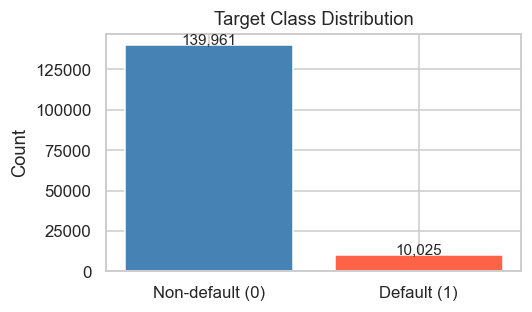

In [6]:
target_counts = df_raw[TARGET_COL].value_counts()
print(target_counts)
print(f"Default rate: {df_raw[TARGET_COL].mean():.2%}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Non-default (0)', 'Default (1)'], target_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/target_distribution.png', bbox_inches='tight')
plt.show()

## 7. Missing Values

In [7]:
from src.data_processing import report_missing
missing = report_missing(df_raw)
print(missing)

                    missing_count  missing_pct
MonthlyIncome               29724    19.817850
NumberOfDependents           3921     2.614244


## 8. Feature Distributions

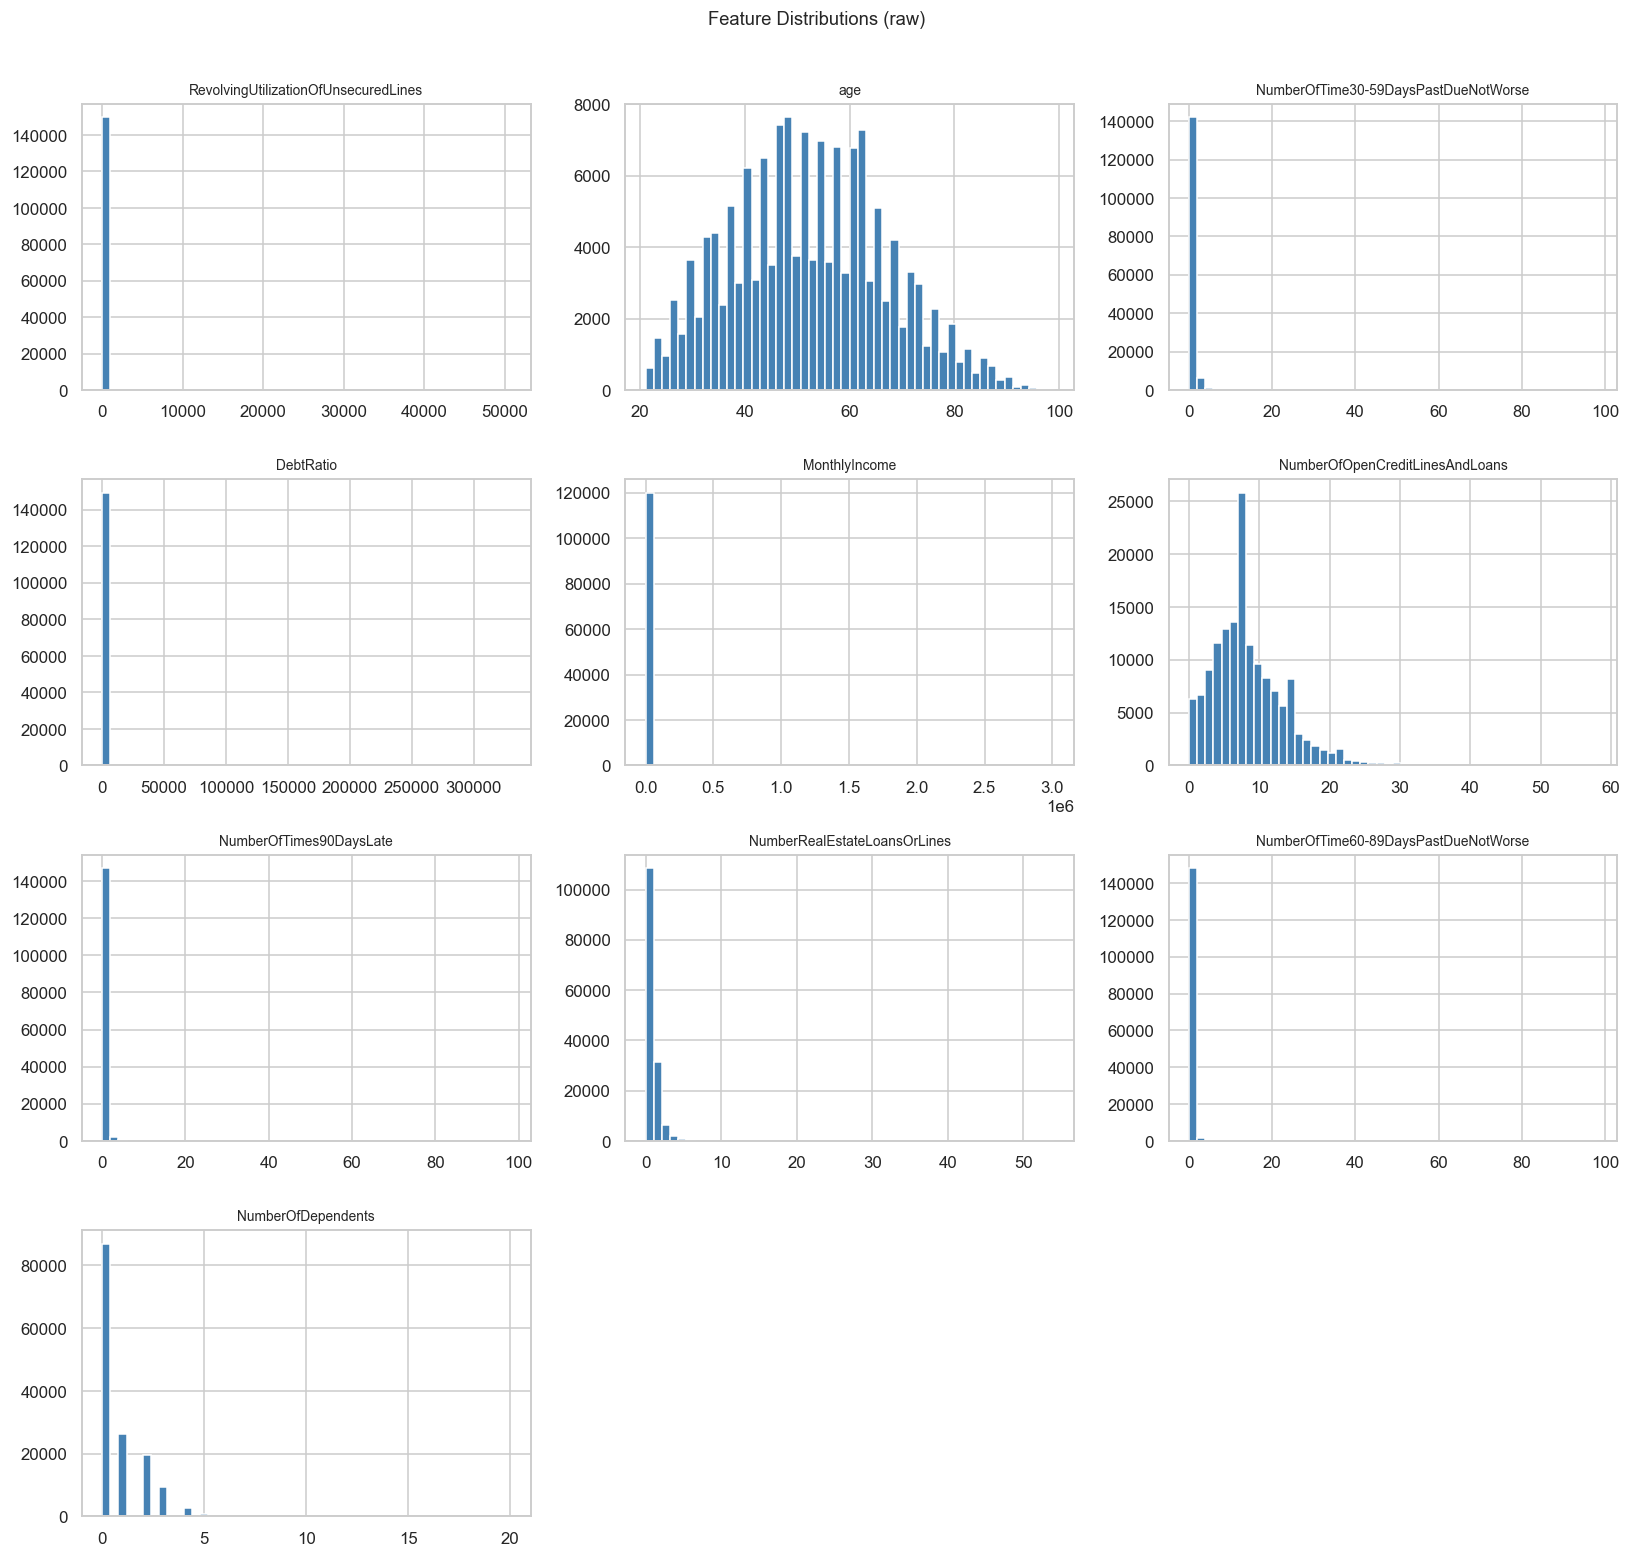

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    df_raw[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions (raw)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_distributions.png', bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap

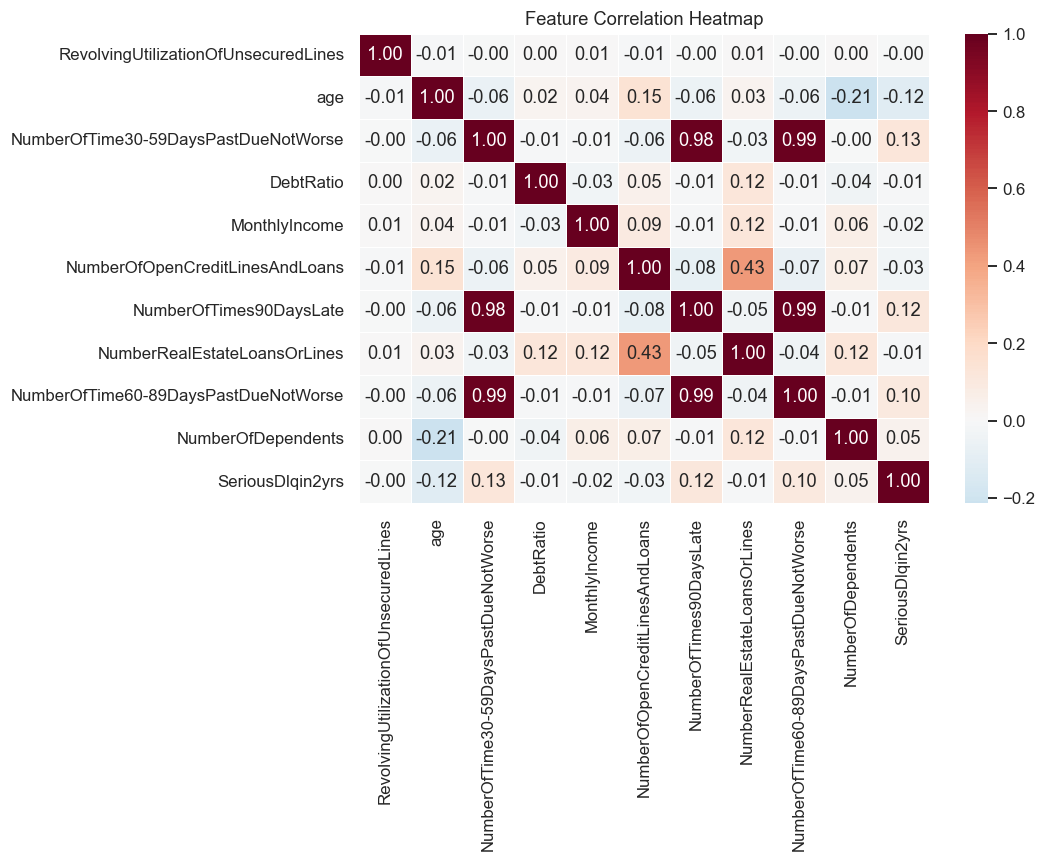

In [9]:
corr = df_raw[FEATURE_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Clean & Feature Engineer

In [10]:
df_clean = impute_missing(df_raw)
df_clean = cap_outliers(df_clean)
df_featured = engineer_features(df_clean)

print(f"Rows after cleaning: {len(df_featured):,}")
df_featured.dtypes

Rows after cleaning: 149,986


borrower_id                                int64
SeriousDlqin2yrs                           int64
RevolvingUtilizationOfUnsecuredLines     float64
age                                        int64
NumberOfTime30-59DaysPastDueNotWorse       int64
DebtRatio                                float64
MonthlyIncome                            float64
NumberOfOpenCreditLinesAndLoans            int64
NumberOfTimes90DaysLate                    int64
NumberRealEstateLoansOrLines               int64
NumberOfTime60-89DaysPastDueNotWorse       int64
NumberOfDependents                       float64
delinquency_severity                       int64
total_past_due_events                      int64
has_90day_late                             int64
utilization_segment                     category
age_bucket                              category
monthly_debt_est                         float64
credit_line_density                      float64
dtype: object

## 11. Save Processed Data

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)
df_featured.to_parquet('../data/processed/features.parquet', index=False)
print("Saved to data/processed/features.parquet")

Saved to data/processed/features.parquet
